In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import boxcox, skew 

# sns.set(style='whitegrid')

In [2]:
df = pd.read_csv('telecom_customer_churn.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           15000 non-null  str    
 1   age                   14550 non-null  float64
 2   gender                15000 non-null  str    
 3   marital_status        15000 non-null  str    
 4   education_level       15000 non-null  str    
 5   location_type         15000 non-null  str    
 6   tenure_months         15000 non-null  int64  
 7   contract_type         15000 non-null  str    
 8   payment_method        15000 non-null  str    
 9   paperless_billing     15000 non-null  str    
 10  auto_payment          15000 non-null  str    
 11  credit_score          14550 non-null  float64
 12  account_status        15000 non-null  str    
 13  total_day_minutes     15000 non-null  float64
 14  total_day_calls       15000 non-null  int64  
 15  total_eve_minutes     15000 no

In [4]:
display(df.head())

,customer_id,age,gender,marital_status,education_level,location_type,tenure_months,contract_type,payment_method,paperless_billing,...,num_support_tickets,num_technical_issues,satisfaction_score,complaint_status,monthly_charges,total_charges,avg_call_charge,late_payment_count,signup_date,churn
0,CUST_00000001,52.0,Male,Married,High School,Suburban,34,Two year,Bank transfer,No,...,1,0,10.0,Resolved,53.42,1721.86,0.9893,0,2021-02-23,No
1,CUST_00000002,42.0,Male,Married,High School,Rural,14,Month-to-month,Credit card,Yes,...,1,0,9.0,Resolved,67.77,968.86,0.7366,0,2022-10-11,No
2,CUST_00000003,54.0,Female,Married,High School,Suburban,40,One year,Credit card,Yes,...,3,1,4.0,Resolved,99.68,3788.89,0.6515,1,2020-08-21,No
3,CUST_00000004,67.0,Female,Divorced,Master,Rural,3,Month-to-month,Electronic check,No,...,7,3,4.0,Resolved,87.57,239.07,0.6584,0,2023-09-26,Yes
4,CUST_00000005,41.0,Female,Married,Master,Suburban,11,Month-to-month,Credit card,Yes,...,3,1,6.0,Resolved,73.58,784.00,0.6454,1,2023-01-16,No


#### Data Cleaning and Preprocessing

In [5]:
string_cols = df.select_dtypes(include=['object', 'string']).columns
print(string_cols)
for col in string_cols:
    df[col] = df[col].astype(str).str.lower()

Index(['customer_id', 'gender', 'marital_status', 'education_level',
       'location_type', 'contract_type', 'payment_method', 'paperless_billing',
       'auto_payment', 'account_status', 'streaming_tv', 'streaming_movies',
       'online_security', 'online_backup', 'device_protection',
       'complaint_status', 'signup_date', 'churn'],
      dtype='str')


In [6]:
df['complaint_status_flag'] = df['complaint_status'].isnull().astype(int)
df['complaint_status'] = df['complaint_status'].fillna('Unknown')

In [7]:
display(df.iloc[12])

customer_id               cust_00000013
age                                48.0
gender                             male
marital_status                  married
education_level                bachelor
location_type                     urban
tenure_months                         1
contract_type            month-to-month
payment_method              credit card
paperless_billing                    no
auto_payment                         no
credit_score                      590.0
account_status                   active
total_day_minutes                178.92
total_day_calls                      85
total_eve_minutes                168.59
total_eve_calls                      38
total_night_minutes               81.16
total_night_calls                    26
data_usage_gb                      8.38
streaming_tv                         no
streaming_movies                     no
online_security                      no
online_backup                        no
device_protection                    no


In [8]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
df['age'] = df['age'].clip(lower=18, upper=90)


print('Age median (used for fill):', age_median)
print(df['age'].describe())

Age median (used for fill): 45.0
count    15000.000000
mean        44.737667
std         14.133333
min         18.000000
25%         35.000000
50%         45.000000
75%         54.000000
max         80.000000
Name: age, dtype: float64


In [9]:
df['credit_score'] = pd.to_numeric(df['credit_score'], errors='coerce')
credit_median = df['credit_score'].median()
df['credit_score'] = df['credit_score'].fillna(credit_median)
# realistic range check
df['credit_score'] = df['credit_score'].clip(lower=300, upper=850)

print(df['credit_score'].describe())

count    15000.000000
mean       679.272467
std         77.729558
min        360.000000
25%        628.000000
50%        679.000000
75%        732.000000
max        850.000000
Name: credit_score, dtype: float64


In [10]:
# satisfaction_score handling

# if text values like Low/Medium/High, map to numeric; otherwise numeric transform
if df['satisfaction_score'].dtype == 'object':
    mapping = {'low':1, 'medium':2, 'high':3, 'very low':1, 'very high':4}
    df['satisfaction_score'] = df['satisfaction_score'].astype(str).str.strip().str.lower().map(mapping).astype('float')

# convert numeric and impute
df['satisfaction_score'] = pd.to_numeric(df['satisfaction_score'], errors='coerce')
sat_median = df['satisfaction_score'].median()
df['satisfaction_score'] = df['satisfaction_score'].fillna(sat_median)


print(df['satisfaction_score'].describe())

count    15000.000000
mean         6.795533
std          1.375059
min          1.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: satisfaction_score, dtype: float64


In [11]:
# monthly_charges handling

# numeric conversion
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')

if 'contract_type' in df.columns:
    monthly_medians = df.groupby('contract_type')['monthly_charges'].median()
    df['monthly_charges'] = df.apply(lambda r: monthly_medians.get(r['contract_type'], r['monthly_charges']) if pd.isna(r['monthly_charges']) else r['monthly_charges'], axis=1)

# fallback global median
monthly_median = df['monthly_charges'].median()
df['monthly_charges'] = df['monthly_charges'].fillna(monthly_median)

# ensure positive
df['monthly_charges'] = df['monthly_charges'].clip(lower=0)

print(df['monthly_charges'].describe())

count    15000.00000
mean        85.14824
std         34.83872
min         20.00000
25%         62.00750
50%         79.45000
75%        101.18250
max        450.00000
Name: monthly_charges, dtype: float64


In [12]:
print('Null counts for all columns:')
print(df.isnull().sum())


Null counts for all columns:
customer_id              0
age                      0
gender                   0
marital_status           0
education_level          0
location_type            0
tenure_months            0
contract_type            0
payment_method           0
paperless_billing        0
auto_payment             0
credit_score             0
account_status           0
total_day_minutes        0
total_day_calls          0
total_eve_minutes        0
total_eve_calls          0
total_night_minutes      0
total_night_calls        0
data_usage_gb            0
streaming_tv             0
streaming_movies         0
online_security          0
online_backup            0
device_protection        0
num_support_tickets      0
num_technical_issues     0
satisfaction_score       0
complaint_status         0
monthly_charges          0
total_charges            0
avg_call_charge          0
late_payment_count       0
signup_date              0
churn                    0
complaint_status_flag    0

In [13]:
display(df)

,customer_id,age,gender,marital_status,education_level,location_type,tenure_months,contract_type,payment_method,paperless_billing,...,num_technical_issues,satisfaction_score,complaint_status,monthly_charges,total_charges,avg_call_charge,late_payment_count,signup_date,churn,complaint_status_flag
0,cust_00000001,52.0,male,married,high school,suburban,34,two year,bank transfer,no,...,0,10.0,resolved,53.42,1721.86,0.9893,0,2021-02-23,no,0
1,cust_00000002,42.0,male,married,high school,rural,14,month-to-month,credit card,yes,...,0,9.0,resolved,67.77,968.86,0.7366,0,2022-10-11,no,0
2,cust_00000003,54.0,female,married,high school,suburban,40,one year,credit card,yes,...,1,4.0,resolved,99.68,3788.89,0.6515,1,2020-08-21,no,0
3,cust_00000004,67.0,female,divorced,master,rural,3,month-to-month,electronic check,no,...,3,4.0,resolved,87.57,239.07,0.6584,0,2023-09-26,yes,0
4,cust_00000005,41.0,female,married,master,suburban,11,month-to-month,credit card,yes,...,1,6.0,resolved,73.58,784.00,0.6454,1,2023-01-16,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,cust_00014996,31.0,female,divorced,high school,suburban,10,month-to-month,bank transfer,yes,...,1,6.0,escalated,57.51,604.07,0.6535,0,2023-02-09,no,0
14996,cust_00014997,63.0,female,divorced,bachelor,suburban,31,two year,electronic check,yes,...,0,7.0,escalated,113.17,3378.87,2.1353,1,2021-05-09,no,0
14997,cust_00014998,64.0,female,single,high school,urban,5,month-to-month,electronic check,yes,...,1,6.0,escalated,49.56,249.88,0.5697,0,2023-07-11,yes,0
14998,cust_00014999,31.0,male,divorced,master,suburban,21,month-to-month,bank transfer,yes,...,4,4.0,escalated,125.88,2589.05,1.1042,1,2022-03-20,no,0


#### Feature Engineering

In [18]:
# Feature Engineering - Focused on Core Drivers

# 1. Target variable: churn as numeric
df['churn_numeric'] = (df['churn'] == 'yes').astype(int)

# 2. Contract type flag (Hypothesis 4 - major churn driver)
df['is_month_to_month'] = (df['contract_type'] == 'month-to-month').astype(int)

# 3. Payment behavior (behavioral signal for churn)
df['late_payment_ratio'] = df['late_payment_count'] / (df['tenure_months'] + 1)

# 4. Support engagement (Hypothesis 5 - support tickets correlate with churn)
df['support_issues_ratio'] = df['num_support_tickets'] / (df['num_technical_issues'] + 1)

# 5. Tenure buckets ( useful for segmentation)
df['tenure_bucket'] = pd.cut(df['tenure_months'], bins=[0, 6, 12, 24, 60, 120], labels=['<6m', '6-12m', '1-2y', '2-5y', '5y+'])


print(f'Total columns: {df.shape[1]}')

Total columns: 41


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   customer_id            15000 non-null  str     
 1   age                    15000 non-null  float64 
 2   gender                 15000 non-null  str     
 3   marital_status         15000 non-null  str     
 4   education_level        15000 non-null  str     
 5   location_type          15000 non-null  str     
 6   tenure_months          15000 non-null  int64   
 7   contract_type          15000 non-null  str     
 8   payment_method         15000 non-null  str     
 9   paperless_billing      15000 non-null  str     
 10  auto_payment           15000 non-null  str     
 11  credit_score           15000 non-null  float64 
 12  account_status         15000 non-null  str     
 13  total_day_minutes      15000 non-null  float64 
 14  total_day_calls        15000 non-null  int64   
 

#### EDA

churn
no     0.725533
yes    0.274467
Name: proportion, dtype: float64


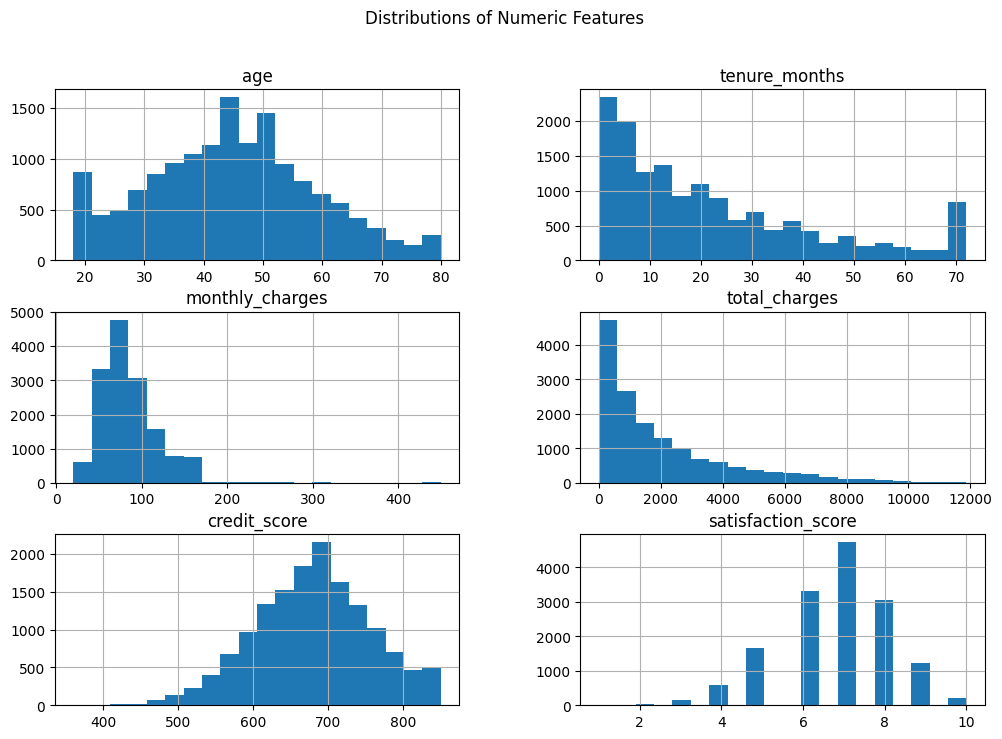

In [ ]:
# EDA: summary stats and distributions

print(df['churn'].value_counts(normalize=True))

# Histograms for key numerics
numeric_cols = ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'credit_score', 'satisfaction_score']
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle('Distributions of Numeric Features')
plt.show()

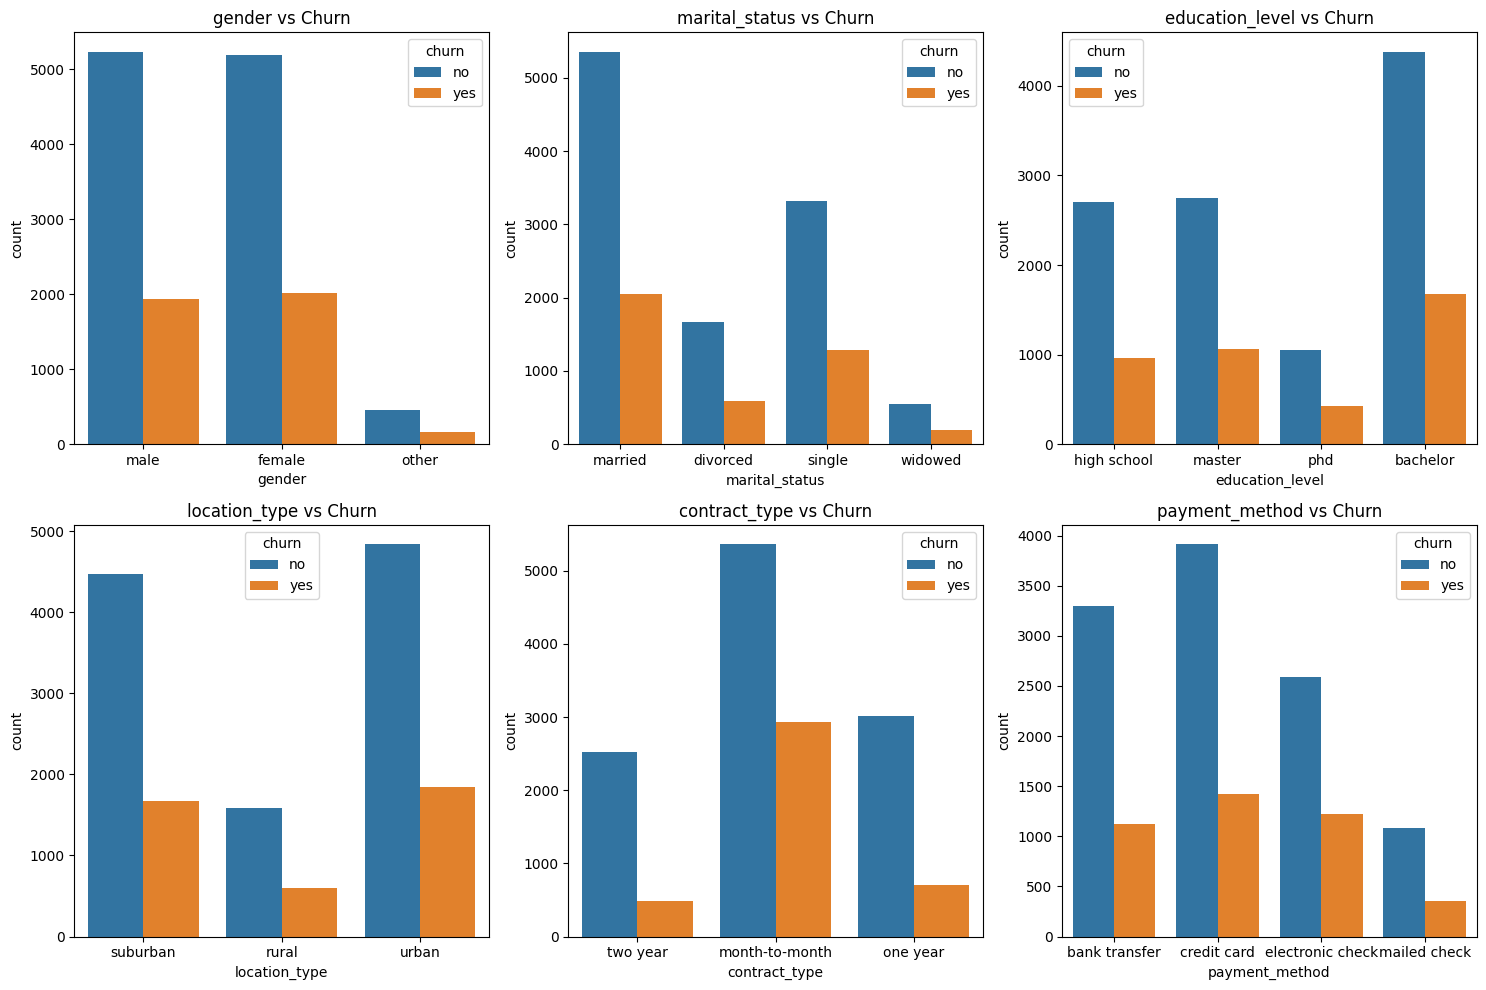

In [ ]:
# EDA: Categorical analysis
categorical_cols = ['gender', 'marital_status', 'education_level', 'location_type', 'contract_type', 'payment_method', 'complaint_status']

# Bar plots for categoricals vs churn
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols[:6]):
    sns.countplot(data=df, x=col, hue='churn', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

Churn unique values: <StringArray>
['no', 'yes']
Length: 2, dtype: str
Churn dtype: str
Correlation with churn:
churn                    1.000000
num_support_tickets      0.140004
num_technical_issues     0.134941
data_usage_gb            0.038339
late_payment_count       0.030329
age                      0.021395
avg_call_charge          0.008599
monthly_charges          0.003889
total_night_calls        0.003020
total_day_minutes        0.002844
total_day_calls          0.001077
total_night_minutes      0.000951
total_eve_minutes       -0.002119
total_eve_calls         -0.006277
credit_score            -0.006534
complaint_status_flag   -0.027985
total_charges           -0.077504
tenure_months           -0.102506
satisfaction_score      -0.141376
Name: churn, dtype: float64


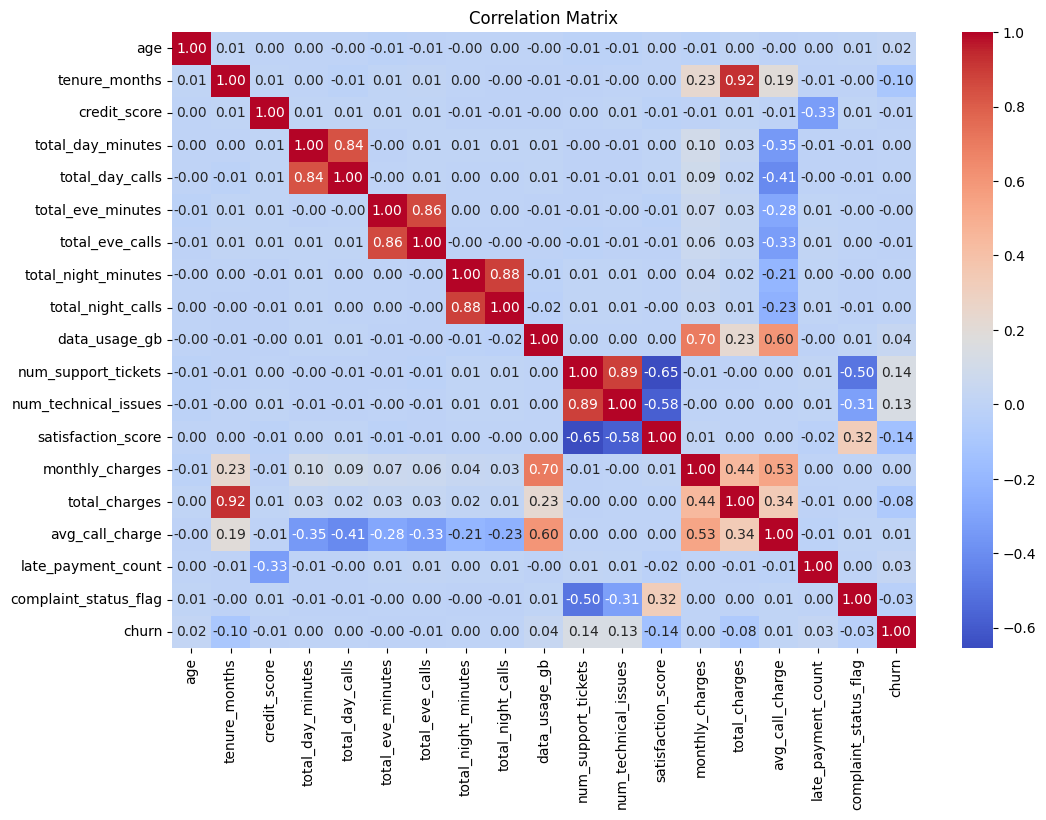

In [ ]:
# EDA: Correlation analysis
# Select numeric columns + churn

corr_df = df.select_dtypes(include=['number']).copy()
if 'churn' in df.columns:
    # Map churn to numeric if it's categorical
    print('Churn unique values:', df['churn'].unique())
    print('Churn dtype:', df['churn'].dtype)
    if str(df['churn'].dtype) in ['object', 'string', 'str']:
        corr_df['churn'] = df['churn'].map({'yes': 1, 'no': 0}).astype(int)
    else:
        corr_df['churn'] = df['churn'].astype(int)
        
corr_matrix = corr_df.corr()
print('Correlation with churn:')
print(corr_matrix['churn'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

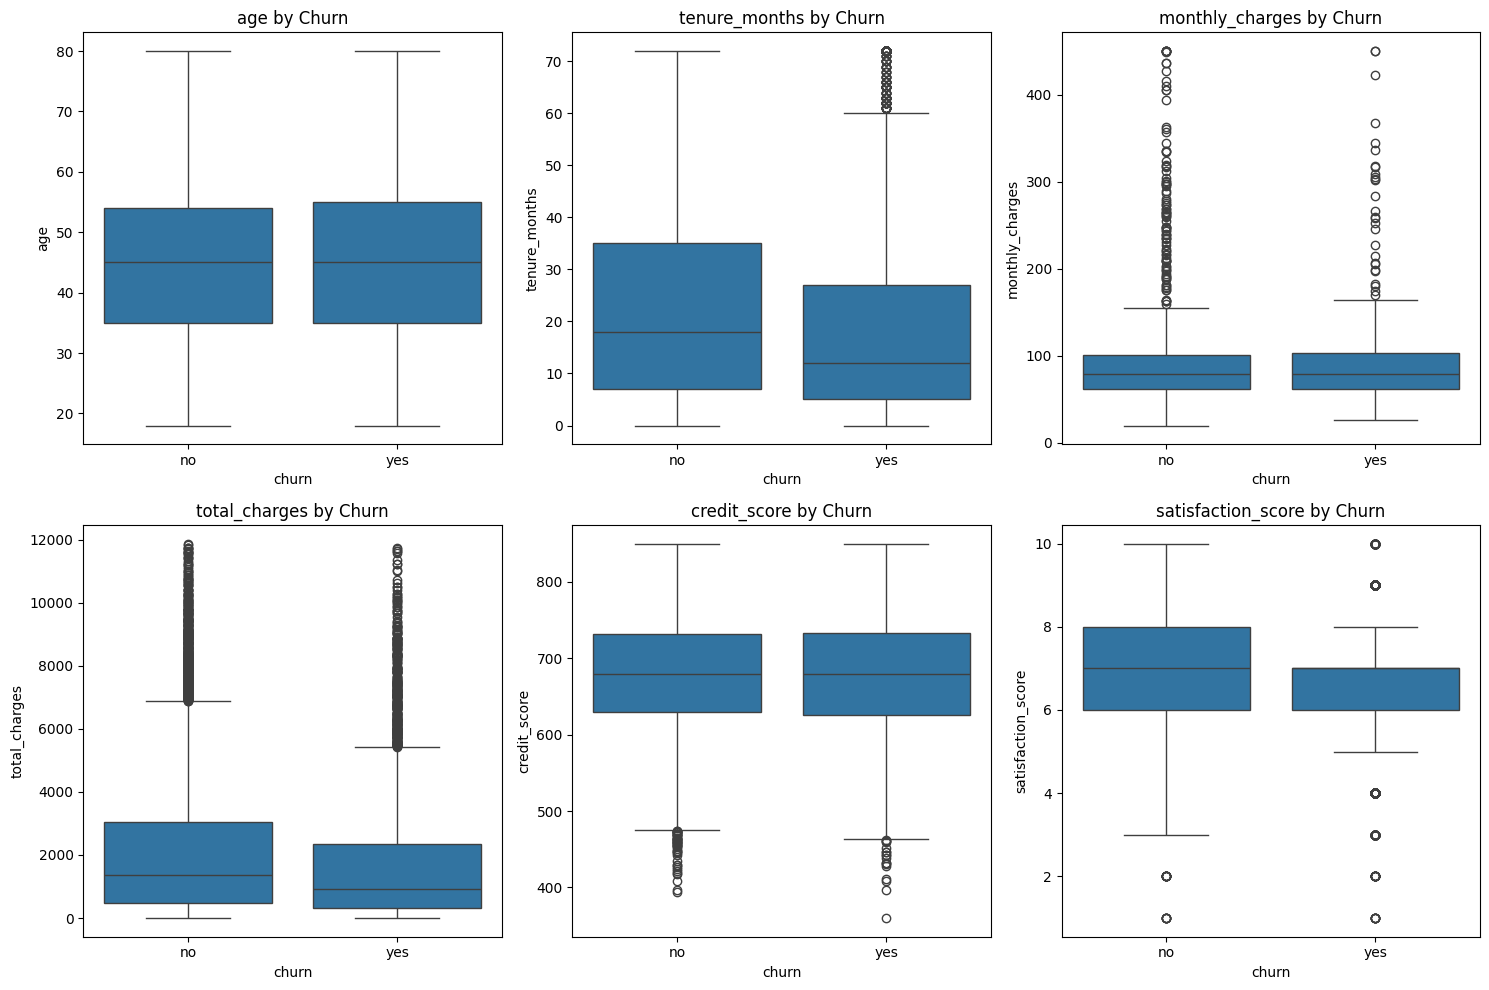

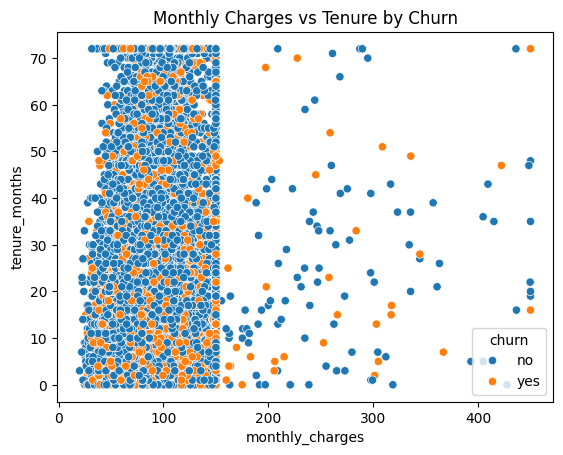

In [ ]:
# EDA: Bivariate insights - churn vs key features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:6]):
    sns.boxplot(data=df, x='churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

# Scatter plots for relationships
sns.scatterplot(data=df, x='monthly_charges', y='tenure_months', hue='churn')
plt.title('Monthly Charges vs Tenure by Churn')
plt.show()

#### Performing skew transformation

In [ ]:
tenure_month_skew = skew(df['tenure_months'].dropna())
print(f'Tenure skewness: {tenure_month_skew:.2f}') 

Tenure skewness: 1.04


tenure_months skew before: 1.0425091268980926


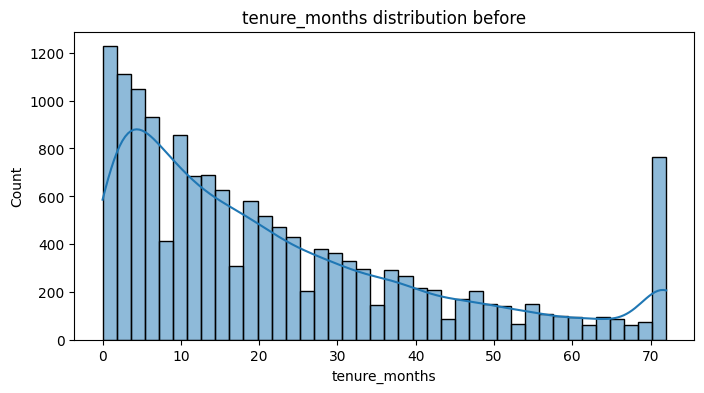

tenure_months skew after sqrt: 0.19332930152601807


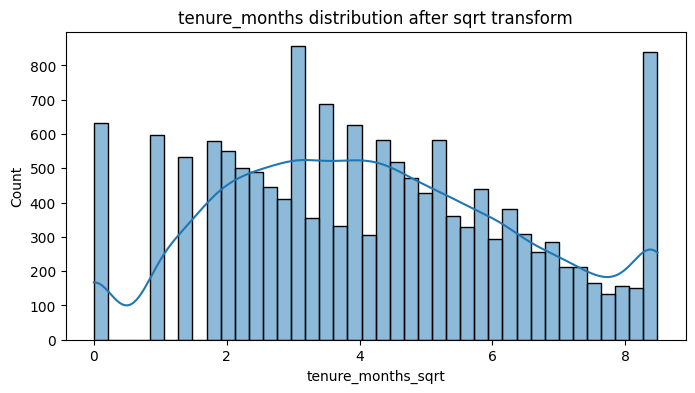

In [ ]:
for col in ['tenure_months']:
    print(col, 'skew before:', df[col].skew())
    df[f'{col}_sqrt'] = np.sqrt(df[col].clip(lower=0))
    

    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f'{col} distribution before')
    plt.show()
    print(col, 'skew after sqrt:', df[f'{col}_sqrt'].skew())

    plt.figure(figsize=(8,4))
    sns.histplot(df[f'{col}_sqrt'], kde=True, bins=40)
    plt.title(f'{col} distribution after sqrt transform')
    plt.show()

total_charges skew before: 1.5888398288597345
Optimal lambda for total_charges: 0.2932537314645949


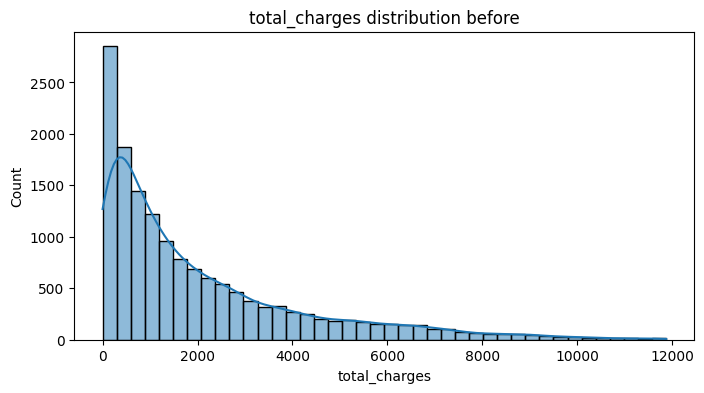

total_charges skew after boxcox: -0.09415445244380817


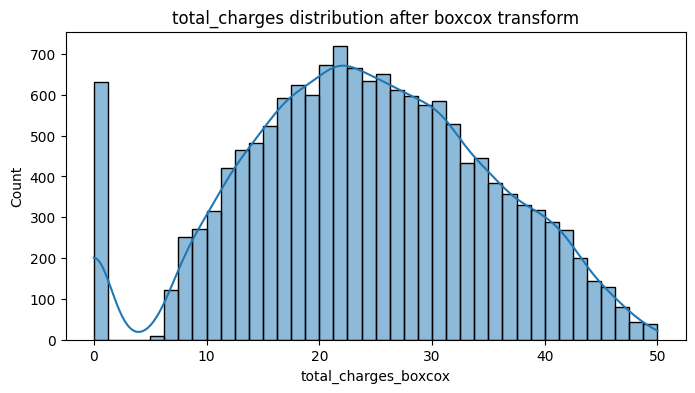

In [ ]:
for col in ['total_charges']:
    print(col, 'skew before:', df[col].skew())
    df[f'{col}_boxcox'], lambda_val = boxcox(df[col] + 1)
    print(f'Optimal lambda for {col}: {lambda_val}')
    
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f'{col} distribution before')
    plt.show()
    print(col, 'skew after boxcox:', df[f'{col}_boxcox'].skew())
    
    plt.figure(figsize=(8,4))
    sns.histplot(df[f'{col}_boxcox'], kde=True, bins=40)
    plt.title(f'{col} distribution after boxcox transform')
    plt.show()

#### Hypothesis Framing and Validation

In [20]:
# Hypothesis 1: Customers with higher monthly charges are more likely to churn
from scipy.stats import ttest_ind

churn_yes = df[df['churn'] == 'yes']['monthly_charges']
churn_no = df[df['churn'] == 'no']['monthly_charges']
t_stat, p_val = ttest_ind(churn_yes, churn_no)
print(f't-stat={t_stat:.2f}, p-value={p_val:.4f}')
print(f'Mean charges - Churn Yes: ${churn_yes.mean():.2f}, No: ${churn_no.mean():.2f}')
print(f'Difference: ${churn_yes.mean() - churn_no.mean():.2f}')
if p_val < 0.05:
    print('RESULT: SIGNIFICANT - Monthly charges differ by churn status')
else:
    print('RESULT: NOT SIGNIFICANT')


t-stat=0.48, p-value=0.6339
Mean charges - Churn Yes: $85.37, No: $85.06
Difference: $0.30
RESULT: NOT SIGNIFICANT


In [21]:
# Hypothesis 2: Shorter tenure leads to higher churn
tenure_churn_yes = df[df['churn'] == 'yes']['tenure_months']
tenure_churn_no = df[df['churn'] == 'no']['tenure_months']
t_stat2, p_val2 = ttest_ind(tenure_churn_yes, tenure_churn_no)
print(f't-stat={t_stat2:.2f}, p-value={p_val2:.4f}')
print(f'Mean tenure - Churn Yes: {tenure_churn_yes.mean():.1f} months, No: {tenure_churn_no.mean():.1f} months')
print(f'Difference: {tenure_churn_no.mean() - tenure_churn_yes.mean():.1f} months')
if p_val2 < 0.05:
    print('RESULT: SIGNIFICANT - Tenure differs by churn status')
else:
    print('RESULT: NOT SIGNIFICANT')


t-stat=-12.62, p-value=0.0000
Mean tenure - Churn Yes: 19.0 months, No: 23.6 months
Difference: 4.6 months
RESULT: SIGNIFICANT - Tenure differs by churn status


In [22]:
# Hypothesis 3: Low satisfaction increases churn risk (chi-square for categorical)
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['satisfaction_score'], df['churn'])
chi2, p_val3, dof, expected = chi2_contingency(contingency)
print(f'chi2={chi2:.2f}, p-value={p_val3:.4f}, dof={dof}')
print('Contingency Table:')
print(contingency)
if p_val3 < 0.05:
    print('RESULT: Significant - Satisfaction and churn are associated')
else:
    print('RESULT: Not Significant - No association between satisfaction and churn')

chi2=407.86, p-value=0.0000, dof=9
Contingency Table:
churn                 no   yes
satisfaction_score            
1.0                    6     7
2.0                   12    15
3.0                   75    80
4.0                  306   295
5.0                 1094   567
6.0                 2219  1084
7.0                 3666  1062
8.0                 2390   665
9.0                  938   294
10.0                 177    48
RESULT: Significant - Satisfaction and churn are associated


In [23]:
# Hypothesis 4: Month-to-month contracts have higher churn
contract_churn = pd.crosstab(df['contract_type'], df['churn'], normalize='index')
print('Churn rates (%) by contract type:')
print((contract_churn * 100).round(2))
max_churn = contract_churn['yes'].max()
min_churn = contract_churn['yes'].min()
max_contract = contract_churn['yes'].idxmax()
min_contract = contract_churn['yes'].idxmin()
risk_ratio = max_churn / min_churn if min_churn > 0 else 0
print(f'\nRESULT: {max_contract} has highest churn ({max_churn*100:.1f}%)')


Churn rates (%) by contract type:
churn              no    yes
contract_type               
month-to-month  64.64  35.36
one year        81.08  18.92
two year        83.87  16.13

RESULT: month-to-month has highest churn (35.4%)


In [24]:
# Hypothesis 5: High support tickets correlate with churn
corr_support = df[['num_support_tickets', 'churn_numeric']].corr().iloc[0,1]
print(f'Correlation coefficient: {corr_support:.3f}')
if abs(corr_support) > 0.2:
    print('RESULT: Moderate correlation')
    if corr_support > 0:
        print('More support tickets correlate with higher churn')
    else:
        print('More support tickets correlate with lower churn')
elif abs(corr_support) > 0.1:
    print('RESULT: Weak correlation')
else:
    print('RESULT: Negligible correlation')

Correlation coefficient: 0.140
RESULT: Weak correlation
